# 0. Load imports 

In [1]:
import pandas as pd
import numpy as np
import re
import gdown #needed to get data from google drive

import matplotlib.pyplot as plt
import seaborn as sns

## print multiple things from same cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

gdown.download(id="1kLQwTZiHZ2h-RdXfFmq8csGqXlPO4r9U", output="df_clean.csv", quiet=False)
df = pd.read_csv("df_clean.csv")

print(df.shape)
print(df.head())



Downloading...
From (original): https://drive.google.com/uc?id=1kLQwTZiHZ2h-RdXfFmq8csGqXlPO4r9U
From (redirected): https://drive.google.com/uc?id=1kLQwTZiHZ2h-RdXfFmq8csGqXlPO4r9U&confirm=t&uuid=781dadfc-6a77-4664-a295-3719b32db5c8
To: /Users/charlesphillips/Documents/GitHub/qss20-final-project/code/df_clean.csv
100%|████████████████████████████████████████| 188M/188M [00:12<00:00, 15.6MB/s]


(378081, 30)
   undl_id ms_code              ms_name ms_vote        date session  \
0   507407     AFG          AFGHANISTAN       Y  2003-12-03      58   
1   507407     ALB              ALBANIA       Y  2003-12-03      58   
2   507407     DZA              ALGERIA       Y  2003-12-03      58   
3   507407     AND              ANDORRA       Y  2003-12-03      58   
4   507407     ATG  ANTIGUA AND BARBUDA       Y  2003-12-03      58   

    resolution                      draft committee_report     meeting  ...  \
0  A/RES/58/20  A/58/L.25|A/58/L.25/Add.1              NaN  A/58/PV.68  ...   
1  A/RES/58/20  A/58/L.25|A/58/L.25/Add.1              NaN  A/58/PV.68  ...   
2  A/RES/58/20  A/58/L.25|A/58/L.25/Add.1              NaN  A/58/PV.68  ...   
3  A/RES/58/20  A/58/L.25|A/58/L.25/Add.1              NaN  A/58/PV.68  ...   
4  A/RES/58/20  A/58/L.25|A/58/L.25/Add.1              NaN  A/58/PV.68  ...   

   year ms_vote_score                       category  us_vote_score  \
0  2003       

/var/folders/cs/x74m_3cj4xv9_rl_f_d37ts40000gn/T/ipykernel_61586/1781338687.py:14: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("df_clean.csv")


# 1. Average Alignments

#### 1.1 Alignment by country and year

In [2]:
alignment = df.groupby(['ms_code', 'ms_name', 'year']).agg(
    us_alignment=('align_us', 'mean'),
    cn_alignment=('align_china', 'mean')
).reset_index()

alignment

,ms_code,ms_name,year,us_alignment,cn_alignment
0,AFG,AFGHANISTAN,2000,0.206897,0.948276
1,AFG,AFGHANISTAN,2001,0.138889,0.930556
2,AFG,AFGHANISTAN,2002,0.128571,0.942857
3,AFG,AFGHANISTAN,2003,0.115385,0.951923
4,AFG,AFGHANISTAN,2004,0.100000,0.963636
...,...,...,...,...,...
4965,ZWE,ZIMBABWE,2021,0.123188,0.921429
4966,ZWE,ZIMBABWE,2022,0.189394,0.915385
4967,ZWE,ZIMBABWE,2023,0.198630,0.868056
4968,ZWE,ZIMBABWE,2024,0.182432,0.905405


#### 1.2 Alignment by country

In [4]:
alignment_just_country = df.groupby('ms_name').agg(
    us_alignment=('align_us', 'mean'),
    cn_alignment=('align_china', 'mean')
).reset_index()

alignment_just_country

,ms_name,us_alignment,cn_alignment
0,AFGHANISTAN,0.149315,0.911196
1,ALBANIA,0.470160,0.623959
2,ALGERIA,0.121452,0.937999
3,ANDORRA,0.412658,0.670674
4,ANGOLA,0.148206,0.909974
...,...,...,...
190,VIET NAM,0.119534,0.927613
191,YEMEN,0.141500,0.914430
192,YUGOSLAVIA,0.404459,0.708333
193,ZAMBIA,0.146791,0.910250


#### 1.3 Alignment by year

In [5]:
alignment_just_year = df.groupby('year').agg(
    us_alignment=('align_us', 'mean'),
    cn_alignment=('align_china', 'mean')
).reset_index()

alignment_just_year

,year,us_alignment,cn_alignment
0,2000,0.319901,0.829707
1,2001,0.284540,0.825851
2,2002,0.238350,0.845096
3,2003,0.238364,0.832597
4,2004,0.232437,0.843641
5,2005,0.226302,0.832698
6,2006,0.236072,0.867916
7,2007,0.198895,0.846967
8,2008,0.199363,0.844295
9,2009,0.280425,0.817865


# 2. Plot of alignment scores across time

<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'Global UN Voting Alignment with US vs China (2000–2025)')

Text(0.5, 0, 'Year')

Text(0, 0.5, 'Alignment Score (0–1)')

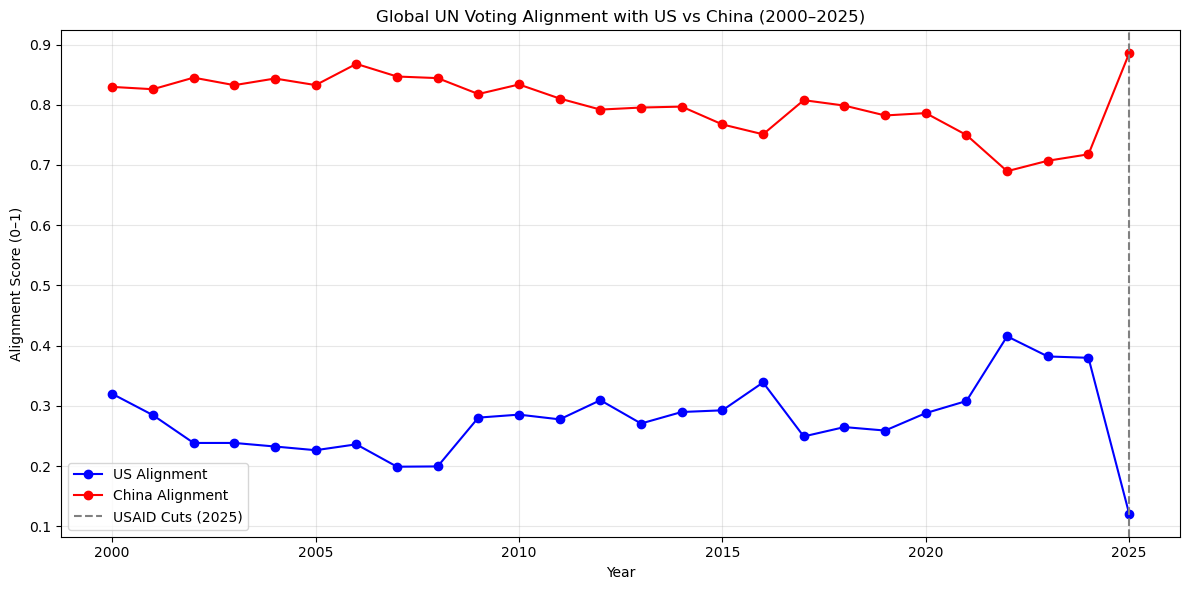

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(alignment_just_year.year, alignment_just_year.us_alignment, 
         marker='o', label='US Alignment', color='blue')
plt.plot(alignment_just_year.year, alignment_just_year.cn_alignment, 
         marker='o', label='China Alignment', color='red')

plt.axvline(x=2025, color='gray', linestyle='--', label='USAID Cuts (2025)')

plt.title('Global UN Voting Alignment with US vs China (2000–2025)')
plt.xlabel('Year')
plt.ylabel('Alignment Score (0–1)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../output/global_alignment_us_vs_china.png', dpi=150, bbox_inches='tight')
plt.tight_layout()

# 3. Graph showing cuts in US foreign assistance.

Coding a graph which just shows how Foreign assistance has changed over the years.
IMPT: each row symbolizes a vote. so the aid and GDP are repeated on each row. Also important to note that i am using the original aid dataset, because when it is combined w the UN votes data is lost (e.g. only kept the ones where US and China were misaligned)

Downloading...
From: https://drive.google.com/uc?id=1olxIzOBAbjpbLfrlvFkPqAfDF2UFe-UI
To: /Users/charlesphillips/Documents/GitHub/qss20-final-project/code/us_foreign_aid_country.csv
100%|██████████████████████████████████████| 2.41M/2.41M [00:00<00:00, 19.2MB/s]


'us_foreign_aid_country.csv'

<Figure size 1200x600 with 0 Axes>

Text(0.5, 0, 'Year')

Text(0, 0.5, 'Total US Foreign Assistance (Constant USD Billions)')

Text(0.5, 1.0, 'US Foreign Assistance Over Time')

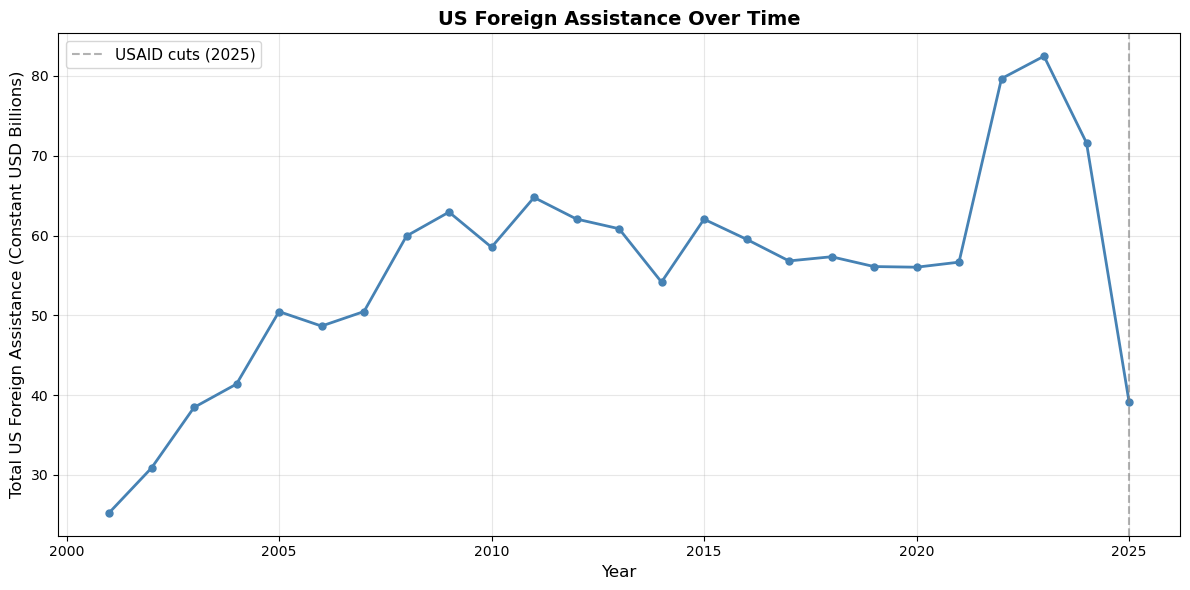

In [12]:
# Reload aid_clean directly so we're not limited by the voting data merge
gdown.download(id="1olxIzOBAbjpbLfrlvFkPqAfDF2UFe-UI", output="us_foreign_aid_country.csv", quiet=False)
aid = pd.read_csv("us_foreign_aid_country.csv")
aid_clean = aid[aid['Transaction Type Name'] == 'Disbursements'].copy()

# Aggregate by year
aid_by_year = aid_clean.groupby('Fiscal Year')['constant_amount'].sum().sort_index().reset_index()
aid_by_year['Fiscal Year'] = aid_by_year['Fiscal Year'].astype(int)
aid_by_year['usaid_bn'] = aid_by_year['constant_amount'] / 1e9

# Drop 2026 - incomplete year
aid_by_year = aid_by_year[aid_by_year['Fiscal Year'] <= 2025]

plt.figure(figsize=(12, 6))
plt.plot(aid_by_year['Fiscal Year'], aid_by_year['usaid_bn'],
         marker='o', markersize=5, color='steelblue', linewidth=2)
plt.axvline(x=2025, color='gray', linestyle='--', alpha=0.6, label='USAID cuts (2025)')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total US Foreign Assistance (Constant USD Billions)', fontsize=12)
plt.title('US Foreign Assistance Over Time', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../output/us_foreign_assistance_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. Diff-in-diff attempt

I first need to work out what the threshold is for treatment

In [13]:
# Get one row per country with their average aid_gdp_ratio pre-2025 to decipher what the threshold is for treatment
aid_reliance = (
    df[df['year'] < 2025]
    .groupby('ms_name')['aid_gdp_ratio']
    .mean()
    .reset_index()
    .sort_values('aid_gdp_ratio', ascending=False)
)

print(aid_reliance.describe())
print(aid_reliance['aid_gdp_ratio'].quantile([0.5, 0.75, 0.90]))
aid_reliance.head(20)

       aid_gdp_ratio
count     187.000000
mean        1.540249
std         6.119382
min         0.000007
25%         0.022969
50%         0.153006
75%         0.904732
max        48.829429
0.50    0.153006
0.75    0.904732
0.90    2.576885
Name: aid_gdp_ratio, dtype: float64


,ms_name,aid_gdp_ratio
107,MARSHALL ISLANDS,48.829429
0,AFGHANISTAN,47.972444
111,MICRONESIA (FEDERATED STATES OF),46.559394
96,LIBERIA,10.787077
130,PALAU,10.389862
160,SOMALIA,6.800253
162,SOUTH SUDAN,6.706482
86,JORDAN,5.312306
80,IRAQ,4.830456
27,BURUNDI,4.364898


plan on using the 75th percentile as threshold as that is 0.9% GDP which is relatively high.

In [14]:
# Define treatment variable
threshold = aid_reliance['aid_gdp_ratio'].quantile(0.75)
print(f"Threshold: {threshold:.3f}% of GDP")

high_aid_countries = aid_reliance[aid_reliance['aid_gdp_ratio'] >= threshold]['ms_name']
print(f"Treated countries: {len(high_aid_countries)}")
print(f"Control countries: {len(aid_reliance) - len(high_aid_countries)}")

# Merge treatment indicator onto main df
df['treated'] = df['ms_name'].isin(high_aid_countries).astype(int)
df['post'] = (df['year'] >= 2025).astype(int)

# Verify
print(df.groupby('treated')['ms_name'].nunique())
print(df['treated'].value_counts())

Threshold: 0.905% of GDP
Treated countries: 47
Control countries: 148
treated
0    148
1     47
Name: ms_name, dtype: int64
treated
0    292164
1     85917
Name: count, dtype: int64


In [15]:

# Post and treated already defined, now create the interaction term
df['did'] = df['treated'] * df['post']

# Aggregate to country-year level (one obs per country-year for the regression)
did_df = df.groupby(['ms_name', 'ms_code', 'year', 'treated', 'post', 'did']).agg(
    align_china=('align_china', 'mean'),
    align_us=('align_us', 'mean'),
    usaid_disbursement=('usaid_disbursement', 'mean'),
    gdp=('gdp', 'mean'),
    aid_gdp_ratio=('aid_gdp_ratio', 'mean')
).reset_index()

print(did_df.shape)
print(did_df.head())

(4970, 11)
       ms_name ms_code  year  treated  post  did  align_china  align_us  \
0  AFGHANISTAN     AFG  2000        1     0    0     0.948276  0.206897   
1  AFGHANISTAN     AFG  2001        1     0    0     0.930556  0.138889   
2  AFGHANISTAN     AFG  2002        1     0    0     0.942857  0.128571   
3  AFGHANISTAN     AFG  2003        1     0    0     0.951923  0.115385   
4  AFGHANISTAN     AFG  2004        1     0    0     0.963636  0.100000   

   usaid_disbursement           gdp  aid_gdp_ratio  
0                 NaN  3.521418e+09            NaN  
1        6.859911e+07  2.813572e+09       2.438150  
2        6.627629e+08  3.825701e+09      17.323958  
3        1.152245e+09  4.520947e+09      25.486810  
4        1.966389e+09  5.224897e+09      37.634975  


In [16]:
import statsmodels.formula.api as smf

# Basic DiD with country and year fixed effects
model = smf.ols(
    'align_china ~ did + C(ms_name) + C(year)',
    data=did_df
).fit(cov_type='HC3')  # heteroskedasticity-robust SEs

print(model.summary())
print(f"\nDiD coefficient: {model.params['did']:.4f}")
print(f"p-value: {model.pvalues['did']:.4f}")

                            OLS Regression Results                            
Dep. Variable:            align_china   R-squared:                       0.905
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     385.7
Date:                Tue, 26 May 2026   Prob (F-statistic):               0.00
Time:                        21:40:10   Log-Likelihood:                 7720.7
No. Observations:                4970   AIC:                        -1.500e+04
Df Residuals:                    4749   BIC:                        -1.356e+04
Df Model:                         220                                         
Covariance Type:                  HC3                                         
                                                          coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------

In [21]:
#### trying a tidier OLS
from linearmodels.panel import PanelOLS

# Set up panel structure
did_panel = did_df.set_index(['ms_name', 'year'])

# Run DiD with country and year fixed effects
model_clean = PanelOLS(
    dependent=did_panel['align_china'],
    exog=did_panel['did'],
    entity_effects=True,   # country fixed effects
    time_effects=True      # year fixed effects
).fit(cov_type='robust')

print(model_clean.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:            align_china   R-squared:                     7.522e-05
Estimator:                   PanelOLS   R-squared (Between):             -0.0001
No. Observations:                4970   R-squared (Within):              -0.0017
Date:                Tue, May 26 2026   R-squared (Overall):             -0.0001
Time:                        21:47:30   Log-likelihood                    7720.7
Cov. Estimator:                Robust                                           
                                        F-statistic:                      0.3572
Entities:                         195   P-value                           0.5501
Avg Obs:                       25.487   Distribution:                  F(1,4749)
Min Obs:                       3.0000                                           
Max Obs:                       26.000   F-statistic (robust):             0.1086
                            

In [27]:
print(df['category'].value_counts())

category
Armed Conflict & Security                80917
Human Rights                             68852
Nuclear Disarmament                      63623
Palestine and the Middle East            47225
Decolonization and Self Determination    41681
Development and Aid                      34969
Environment                              14226
UN Institutional                         13349
Economic and Trade                       12031
Other                                     1208
Name: count, dtype: int64


In [29]:
# Build DiD at resolution level (not averaged by year)
# Use df directly which has category on every row 

## this is by category

# Step 1: define treated countries (same as your existing did_df)
treated_countries = did_df[did_df['treated'] == 1]['ms_name'].unique()

# Step 2: build resolution-level DiD dataset from df
did_res = df[['ms_name', 'year', 'resolution', 'category', 
              'align_china', 'usaid_disbursement']].copy()

did_res['treated'] = did_res['ms_name'].isin(treated_countries).astype(int)
did_res['post'] = (did_res['year'] >= 2025).astype(int)
did_res['did'] = did_res['treated'] * did_res['post']

# Step 3: loop by category
from linearmodels.panel import PanelOLS

results = {}

for cat in did_res['category'].unique():
    subset = did_res[did_res['category'] == cat].copy()
    subset = subset.dropna(subset=['align_china'])
    
    # need variation in did
    if subset['did'].sum() < 10:
        continue
    
    panel = subset.set_index(['ms_name', 'year'])
    
    try:
        model = PanelOLS(
            dependent=panel['align_china'],
            exog=panel['did'],
            entity_effects=True,
            time_effects=True
        ).fit(cov_type='robust')
        
        results[cat] = {
            'coef': model.params['did'],
            'pval': model.pvalues['did'],
            'nobs': model.nobs
        }
        print(f"{cat}: coef={model.params['did']:.4f}, p={model.pvalues['did']:.3f}, n={model.nobs}")
    
    except Exception as e:
        print(f"{cat} failed: {e}")

results_df = pd.DataFrame(results).T.sort_values('coef')
print(results_df)

Palestine and the Middle East: coef=0.0042, p=0.541, n=47225
Armed Conflict & Security: coef=0.0147, p=0.032, n=78593
Nuclear Disarmament: coef=0.0085, p=0.433, n=63100
Human Rights: coef=-0.0366, p=0.000, n=68687
Economic and Trade: coef=-0.0037, p=0.617, n=12031
Development and Aid: coef=-0.0322, p=0.000, n=34969
Decolonization and Self Determination: coef=0.0106, p=0.041, n=40705
Environment: coef=0.0120, p=0.050, n=14069
UN Institutional: coef=-0.0809, p=0.000, n=13195
Other: coef=0.0542, p=0.233, n=1208
                                           coef          pval     nobs
UN Institutional                      -0.080864  2.442491e-15  13195.0
Human Rights                          -0.036646  1.593053e-07  68687.0
Development and Aid                   -0.032158  1.134648e-13  34969.0
Economic and Trade                    -0.003700  6.174321e-01  12031.0
Palestine and the Middle East          0.004244  5.411242e-01  47225.0
Nuclear Disarmament                    0.008486  4.331786e-0

In [26]:
# Step 1: Redefine treatment based on recent aid reliance (2020-2024)
recent_reliance = (
    df[(df['year'] >= 2010) & (df['year'] < 2025)]
    .groupby('ms_name')['aid_gdp_ratio']
    .mean()
    .reset_index()
    .rename(columns={'aid_gdp_ratio': 'recent_aid_gdp'})
)

threshold_new = recent_reliance['recent_aid_gdp'].quantile(0.75)
print(f"New threshold: {threshold_new:.3f}% of GDP")

high_aid_countries_new = recent_reliance[recent_reliance['recent_aid_gdp'] >= threshold_new]['ms_name']
print(f"Treated: {len(high_aid_countries_new)}, Control: {len(recent_reliance) - len(high_aid_countries_new)}")

# Step 2: Merge back and redefine did
df = df.merge(recent_reliance, on='ms_name', how='left')
df['treated'] = df['ms_name'].isin(high_aid_countries_new).astype(int)
df['post'] = (df['year'] >= 2025).astype(int)
df['did'] = df['treated'] * df['post']

# Step 3: Reaggregate
did_df = df.groupby(['ms_name', 'ms_code', 'year', 'treated', 'post', 'did']).agg(
    align_china=('align_china', 'mean'),
    align_us=('align_us', 'mean'),
    aid_gdp_ratio=('aid_gdp_ratio', 'mean')
).reset_index()

# Step 4: Rerun DiD
from linearmodels.panel import PanelOLS

did_panel = did_df.set_index(['ms_name', 'year'])

model_clean = PanelOLS(
    dependent=did_panel['align_china'],
    exog=did_panel['did'],
    entity_effects=True,
    time_effects=True
).fit(cov_type='robust')

print(model_clean.summary)

New threshold: 0.688% of GDP
Treated: 47, Control: 146


MergeError: Passing 'suffixes' which cause duplicate columns {'recent_aid_gdp_x'} is not allowed.

    year          coef        ci_low       ci_high          pval
0   2000  1.861219e+09  1.219148e+09  2.503291e+09  1.335252e-08
1   2001  1.861219e+09  1.219148e+09  2.503291e+09  1.335252e-08
2   2002  1.861219e+09  1.219148e+09  2.503291e+09  1.335252e-08
3   2003  1.861219e+09  1.219148e+09  2.503291e+09  1.335252e-08
4   2004  1.861219e+09  1.219148e+09  2.503291e+09  1.335252e-08
5   2005  1.861219e+09  1.219148e+09  2.503291e+09  1.335252e-08
6   2006  1.861219e+09  1.219148e+09  2.503291e+09  1.335252e-08
7   2007  1.861219e+09  1.219148e+09  2.503291e+09  1.335252e-08
8   2008  1.861219e+09  1.219148e+09  2.503291e+09  1.335252e-08
9   2009  1.861219e+09  1.219148e+09  2.503291e+09  1.335252e-08
10  2010  1.861219e+09  1.219148e+09  2.503291e+09  1.335252e-08
11  2011  1.861219e+09  1.219148e+09  2.503291e+09  1.335252e-08
12  2012  1.861219e+09  1.219148e+09  2.503291e+09  1.335252e-08
13  2013  1.861219e+09  1.219148e+09  2.503291e+09  1.335252e-08
14  2014  1.861219e+09  1

<Figure size 1200x600 with 0 Axes>

Text(0.5, 0, 'Year')

Text(0, 0.5, 'Treated vs Control Difference in China Alignment')

Text(0.5, 1.0, 'Parallel Trends Test — Event Study')

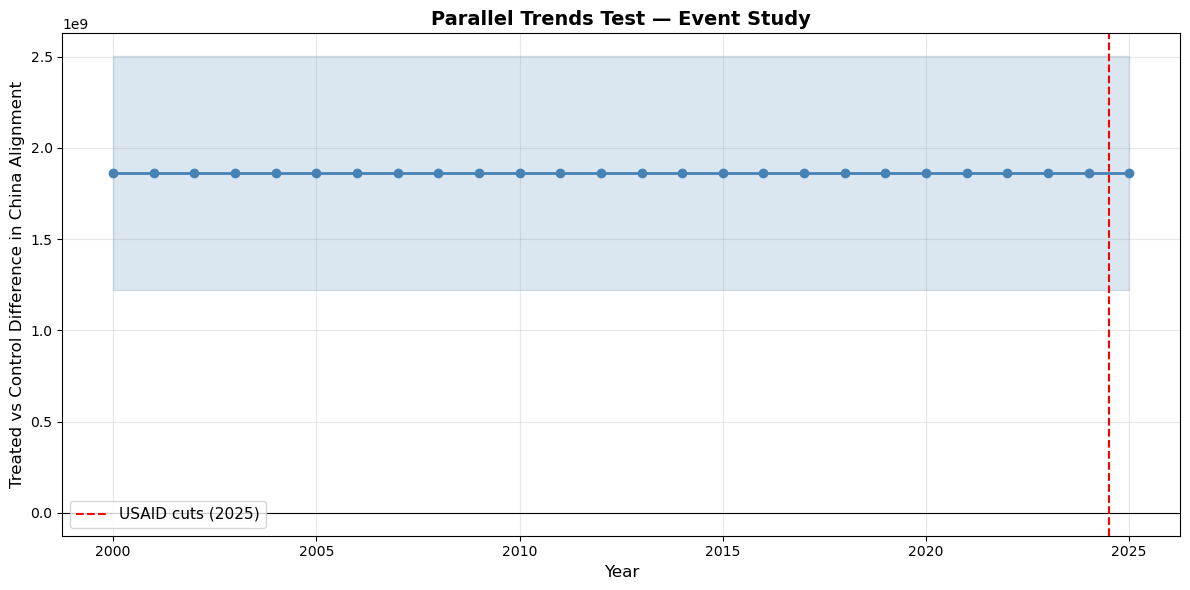

In [17]:
# 5. Parallel Trends Test
# Interact treated with each year dummy (pre-2025 only)
# If parallel trends holds, these interaction coefficients should be ~0 and insignificant

did_df['year'] = did_df['year'].astype(int)

# Run event study regression
model_pt = smf.ols(
    'align_china ~ treated:C(year) + C(ms_name) + C(year)',
    data=did_df
).fit(cov_type='HC3')

# Extract the treated x year interaction coefficients
import re
coefs = model_pt.params
cis = model_pt.conf_int()
pvals = model_pt.pvalues

event_rows = [(k, coefs[k], cis.loc[k, 0], cis.loc[k, 1], pvals[k]) 
              for k in coefs.index if 'treated:C(year)' in k]

event_df = pd.DataFrame(event_rows, columns=['term', 'coef', 'ci_low', 'ci_high', 'pval'])
event_df['year'] = event_df['term'].str.extract(r'(\d{4})').astype(int)
event_df = event_df.sort_values('year')

print(event_df[['year', 'coef', 'ci_low', 'ci_high', 'pval']].to_string())

# Plot
plt.figure(figsize=(12, 6))
plt.plot(event_df['year'], event_df['coef'], marker='o', color='steelblue', linewidth=2)
plt.fill_between(event_df['year'], event_df['ci_low'], event_df['ci_high'], alpha=0.2, color='steelblue')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
plt.axvline(x=2024.5, color='red', linestyle='--', label='USAID cuts (2025)')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Treated vs Control Difference in China Alignment', fontsize=12)
plt.title('Parallel Trends Test — Event Study', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../output/parallel_trends.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
print(did_df['treated'].dtype)
print(did_df['treated'].value_counts())
print(did_df['align_china'].describe())

int64
treated
0    3780
1    1190
Name: count, dtype: int64
count    4970.000000
mean        0.803243
std         0.165991
min         0.000000
25%         0.695652
50%         0.865079
75%         0.926206
max         1.000000
Name: align_china, dtype: float64


In [19]:
print(did_df['year'].value_counts().sort_index())

year
2000    183
2001    179
2002    187
2003    189
2004    191
2005    191
2006    193
2007    192
2008    192
2009    192
2010    192
2011    193
2012    193
2013    193
2014    193
2015    193
2016    193
2017    193
2018    193
2019    193
2020    193
2021    193
2022    192
2023    192
2024    191
2025    191
Name: count, dtype: int64
